# DATA MINING PROJECT

In [51]:
import numpy as np
import pandas as pd
import math
import seaborn as sns
import matplotlib.pyplot as plt
from pprint import pprint
import os

#for data preparation
from sklearn.preprocessing import OneHotEncoder #for dummy variables
from sklearn.impute import SimpleImputer # for handling missing data
from sklearn.preprocessing import LabelEncoder # for encoding label data
from sklearn.preprocessing import StandardScaler # for standardizing the data
from sklearn.preprocessing import OneHotEncoder # for one-hot encoding categorical data

#for regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

#for classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score

import statsmodels.api as sm
import statsmodels.formula.api as sms #or smf

#for KNN
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

#for DecisionTree
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import export_graphviz
import cv2
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

#for RandomForest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC


## Data Preparation

In [ ]:
#Accidents Data: https://drive.google.com/file/d/1cIXSGq9YmYwnUU9H4eaiyvnd05tSEhaq/view?usp=sharing
#Vecicle Data: https://drive.google.com/file/d/13kbB2EH2iyr-8Ju2KoIXsdTBPq1rVC17/view?usp=sharing
#Casualty Data: https://drive.google.com/file/d/1retPZMkUs4GFajH1Khqch6E-cFmmyQ7_/view?usp=sharing

Drive Mounting: Update according to your drive path

In [2]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
import os
os.chdir("/content/gdrive/MyDrive/Zicklin/CIS9660/Programs")

File Reading

In [54]:
df_accident = pd.read_csv('/content/gdrive/MyDrive/Zicklin/CIS9660/Programs/Project9660/Accidents0514.csv')

<ipython-input-54-9ce9b54d492e>:1: DtypeWarning: Columns (31) have mixed types. Specify dtype option on import or set low_memory=False.
  df_accident = pd.read_csv('/content/gdrive/MyDrive/Zicklin/CIS9660/Programs/Project9660/Accidents0514.csv')


In [55]:
df_accident.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1640597 entries, 0 to 1640596
Data columns (total 32 columns):
 #   Column                                       Non-Null Count    Dtype  
---  ------                                       --------------    -----  
 0   Accident_Index                               1640597 non-null  object 
 1   Location_Easting_OSGR                        1640486 non-null  float64
 2   Location_Northing_OSGR                       1640486 non-null  float64
 3   Longitude                                    1640486 non-null  float64
 4   Latitude                                     1640486 non-null  float64
 5   Police_Force                                 1640597 non-null  int64  
 6   Accident_Severity                            1640597 non-null  int64  
 7   Number_of_Vehicles                           1640597 non-null  int64  
 8   Number_of_Casualties                         1640597 non-null  int64  
 9   Date                                         1

In [56]:
dfaccident = df_accident[['Accident_Index', 'Accident_Severity', 'Number_of_Vehicles', 'Number_of_Casualties', 'Date', 'Day_of_Week', 'Time', 'Light_Conditions', 'Weather_Conditions', 'Road_Surface_Conditions', 'Road_Type', 'Speed_limit', 'Urban_or_Rural_Area' ]]

In [57]:
dfaccident

,Accident_Index,Accident_Severity,Number_of_Vehicles,Number_of_Casualties,Date,Day_of_Week,Time,Light_Conditions,Weather_Conditions,Road_Surface_Conditions,Road_Type,Speed_limit,Urban_or_Rural_Area
0,200501BS00001,2,1,1,04/01/2005,3,17:42,1,2,2,6,30,1
1,200501BS00002,3,1,1,05/01/2005,4,17:36,4,1,1,3,30,1
2,200501BS00003,3,2,1,06/01/2005,5,00:15,4,1,1,6,30,1
3,200501BS00004,3,1,1,07/01/2005,6,10:35,1,1,1,6,30,1
4,200501BS00005,3,1,1,10/01/2005,2,21:13,7,1,2,6,30,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1640592,2014984136414,2,2,1,07/12/2014,1,22:20,6,3,3,3,70,2
1640593,2014984137514,3,2,2,11/12/2014,5,06:40,6,1,3,3,70,2
1640594,2014984137714,3,1,1,09/12/2014,3,02:00,4,1,4,6,40,2
1640595,2014984138414,2,3,2,17/12/2014,4,06:55,6,2,2,6,60,2


In [58]:
dfaccident.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1640597 entries, 0 to 1640596
Data columns (total 13 columns):
 #   Column                   Non-Null Count    Dtype 
---  ------                   --------------    ----- 
 0   Accident_Index           1640597 non-null  object
 1   Accident_Severity        1640597 non-null  int64 
 2   Number_of_Vehicles       1640597 non-null  int64 
 3   Number_of_Casualties     1640597 non-null  int64 
 4   Date                     1640597 non-null  object
 5   Day_of_Week              1640597 non-null  int64 
 6   Time                     1640464 non-null  object
 7   Light_Conditions         1640597 non-null  int64 
 8   Weather_Conditions       1640597 non-null  int64 
 9   Road_Surface_Conditions  1640597 non-null  int64 
 10  Road_Type                1640597 non-null  int64 
 11  Speed_limit              1640597 non-null  int64 
 12  Urban_or_Rural_Area      1640597 non-null  int64 
dtypes: int64(10), object(3)
memory usage: 162.7+ MB


In [ ]:
#ReplaceMissingValues
#dfaccident.replace(-1, np.nan, inplace=True)

In [59]:
dfaccident.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1640597 entries, 0 to 1640596
Data columns (total 13 columns):
 #   Column                   Non-Null Count    Dtype 
---  ------                   --------------    ----- 
 0   Accident_Index           1640597 non-null  object
 1   Accident_Severity        1640597 non-null  int64 
 2   Number_of_Vehicles       1640597 non-null  int64 
 3   Number_of_Casualties     1640597 non-null  int64 
 4   Date                     1640597 non-null  object
 5   Day_of_Week              1640597 non-null  int64 
 6   Time                     1640464 non-null  object
 7   Light_Conditions         1640597 non-null  int64 
 8   Weather_Conditions       1640597 non-null  int64 
 9   Road_Surface_Conditions  1640597 non-null  int64 
 10  Road_Type                1640597 non-null  int64 
 11  Speed_limit              1640597 non-null  int64 
 12  Urban_or_Rural_Area      1640597 non-null  int64 
dtypes: int64(10), object(3)
memory usage: 162.7+ MB


In [60]:
dfaccident.isna().sum()

,0
Accident_Index,0
Accident_Severity,0
Number_of_Vehicles,0
Number_of_Casualties,0
Date,0
Day_of_Week,0
Time,133
Light_Conditions,0
Weather_Conditions,0
Road_Surface_Conditions,0


In [61]:
dfaccident['Accident_Severity'].value_counts()
#Original Data is 3: Slight, 2: Serious, 1: Fatal.
#Needs to be reversed that Higher the number, the more serious it is

,count
Accident_Severity,
3,1397173
2,222042
1,21382


In [62]:
#recoding Accident Severity to Reverse
dfaccident['Accident_Severity'] = dfaccident['Accident_Severity'].replace({
    1: 3,
    2: 2,
    3: 1,
})
dfaccident['Accident_Severity'].value_counts()

<ipython-input-62-2724e39e833a>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfaccident['Accident_Severity'] = dfaccident['Accident_Severity'].replace({


,count
Accident_Severity,
1,1397173
2,222042
3,21382


In [63]:
dfaccident['Accident_Severity3Category'] = dfaccident['Accident_Severity'].replace({
    1: "Slight",
    2: "Serious",
    3: "Fatal",
})
dfaccident['Accident_Severity3Category'].value_counts()

<ipython-input-63-2ccc047508ba>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfaccident['Accident_Severity3Category'] = dfaccident['Accident_Severity'].replace({


,count
Accident_Severity3Category,
Slight,1397173
Serious,222042
Fatal,21382


In [64]:
dfaccident['Accident_Severity2Category'] = dfaccident['Accident_Severity'].replace({
    1: "Slight",
    2: "Serious",
    3: "Serious",
})
dfaccident['Accident_Severity2Category'].value_counts()

<ipython-input-64-f21834ad74ed>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfaccident['Accident_Severity2Category'] = dfaccident['Accident_Severity'].replace({


,count
Accident_Severity2Category,
Slight,1397173
Serious,243424


In [65]:
#dfaccident['Number_of_Vehicles'].value_counts() #noproblems
#dfaccident['Number_of_Casualties'].value_counts() #noproblems

In [66]:
dfaccident['Date'] = pd.to_datetime(dfaccident['Date'], format='%d/%m/%Y')

# Extract month and year into new columns
dfaccident['Month'] = dfaccident['Date'].dt.month
dfaccident['Year'] = dfaccident['Date'].dt.year

<ipython-input-66-e850f222fda5>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfaccident['Date'] = pd.to_datetime(dfaccident['Date'], format='%d/%m/%Y')
<ipython-input-66-e850f222fda5>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfaccident['Month'] = dfaccident['Date'].dt.month
<ipython-input-66-e850f222fda5>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: htt

In [67]:
dfaccident['Month'].value_counts()

,count
Month,
11,150406
10,148772
7,143853
9,141153
5,139149
6,139115
8,134344
12,134232
3,131544


In [68]:
dfaccident['Year'].value_counts()

,count
Year,
2005,198735
2006,189161
2007,182115
2008,170591
2009,163554
2010,154414
2011,151474
2014,146322
2012,145571


In [69]:
dfaccident['Day_of_Week'].value_counts().sort_index()

,count
Day_of_Week,
1,180068
2,233238
3,245275
4,247022
5,246015
6,268985
7,219994


In [70]:
dfaccident['Day_of_Week'] = dfaccident['Day_of_Week'].replace({
    1: 'Sun',
    2: 'Mon',
    3: 'Tue',
    4: 'Wed',
    5: 'Thu',
    6: 'Fri',
    7: 'Sat'
})
dfaccident['Day_of_Week'].value_counts()

<ipython-input-70-96085d3339f5>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfaccident['Day_of_Week'] = dfaccident['Day_of_Week'].replace({


,count
Day_of_Week,
Fri,268985
Wed,247022
Thu,246015
Tue,245275
Mon,233238
Sat,219994
Sun,180068


In [71]:
#adding a Weekday Weekend Column
dfaccident['WeekdayEnd'] = dfaccident['Day_of_Week'].replace({
    'Sun': 'Weekend',
    'Mon': 'Weekday',
    'Tue': 'Weekday',
    'Wed': 'Weekday',
    'Thu': 'Weekday',
    'Fri': 'Weekday',
    'Sat': 'Weekend'
})
dfaccident['WeekdayEnd'].value_counts()

<ipython-input-71-a92565a94d81>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfaccident['WeekdayEnd'] = dfaccident['Day_of_Week'].replace({


,count
WeekdayEnd,
Weekday,1240535
Weekend,400062


In [72]:
dfaccident['Hour'] = pd.to_datetime(dfaccident['Time'], format='%H:%M').dt.hour
dfaccident['Hour'].value_counts().sort_index()

<ipython-input-72-6de933e68acf>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfaccident['Hour'] = pd.to_datetime(dfaccident['Time'], format='%H:%M').dt.hour


,count
Hour,
0.0,25231
1.0,18508
2.0,14907
3.0,11910
4.0,9117
5.0,13135
6.0,28320
7.0,68200
8.0,120052


In [73]:
#Time has Missing Value, Manual Replace with mode of 17
dfaccident['Time'].fillna(17, inplace=True)
dfaccident['Hour'].fillna(17, inplace=True)

<ipython-input-73-693ef25f0863>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dfaccident['Time'].fillna(17, inplace=True)
<ipython-input-73-693ef25f0863>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfaccident['Time'].fillna(17, inplace=True)
<ipython-input-73-693ef25f0863>:3: FutureWarning: A value is trying to be set on a copy of a Da

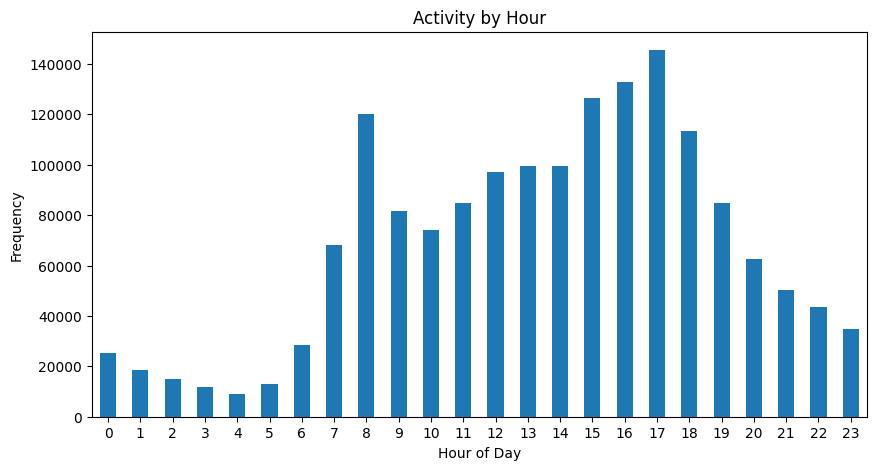

In [74]:
hour_counts=dfaccident['Hour'].value_counts().sort_index()
all_hours = pd.Series(0, index=np.arange(24))
hour_counts = all_hours.add(hour_counts, fill_value=0).astype(int)

plt.figure(figsize=(10, 5))
hour_counts.plot(kind='bar')
plt.xlabel('Hour of Day')
plt.ylabel('Frequency')
plt.title('Activity by Hour')
plt.xticks(rotation=0)
#plt.grid(axis='y', linestyle='--', alpha=0.7)
#plt.tight_layout()
plt.show()

In [75]:
dfaccident['Light_Conditions'].value_counts()
#needed to be recoded as intervals are 1-4-6-7-5

,count
Light_Conditions,
1,1201866
4,322177
6,91689
7,17399
5,7466


In [76]:
#Darkness recoded for equal intervals
#Higher number, darker
dfaccident['Light_Conditions'] = dfaccident['Light_Conditions'].replace({
    1: 1, #Daylight
    4: 2, #DarknessLit
    5: 3, #DarknessUnlit
    6: 3, #DarknessUnlit <-- Recoded from No lighting Still Darkness
    7: 2, #DarknessUnknown <-- Reoded from Darkeness Unknown to Lit as Mode
})
dfaccident['Light_Conditions'].value_counts()

<ipython-input-76-e6c34043adde>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfaccident['Light_Conditions'] = dfaccident['Light_Conditions'].replace({


,count
Light_Conditions,
1,1201866
2,339576
3,99155


In [77]:
dfaccident['Weather_Conditions'].value_counts()

,count
Weather_Conditions,
1,1309195
2,194930
8,37179
9,31651
5,23490
4,20960
3,11860
7,9037
6,2134


In [78]:
#Extracting Wind
dfaccident['Wind'] = dfaccident['Weather_Conditions'].replace({
    1: 'Normal',
    2: 'Normal',
    3: 'Normal',
    4: 'HighWind',
    5: 'HighWind',
    6: 'HighWind',
    7: 'Normal',
    8: 'Normal',
    9: 'Normal',
    -1: 'Normal'
})

<ipython-input-78-aa635ed4729d>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfaccident['Wind'] = dfaccident['Weather_Conditions'].replace({


In [79]:
dfaccident['Wind'].value_counts()

,count
Wind,
Normal,1594013
HighWind,46584


In [80]:
dfaccident['Precipitation'] = dfaccident['Weather_Conditions'].replace({
    1: 'Fine',
    2: 'Rain',
    3: 'Snow',
    4: 'Fine',
    5: 'Rain',
    6: 'Snow',
    7: 'Fog',
    8: 'Fine', #fine is mode 8 is others
    9: 'Fine', #fine is mode 9 is unknown
    -1: 'Fine'
})
dfaccident['Precipitation'].value_counts()

<ipython-input-80-d3ff64e5e575>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfaccident['Precipitation'] = dfaccident['Weather_Conditions'].replace({


,count
Precipitation,
Fine,1399146
Rain,218420
Snow,13994
Fog,9037


In [81]:
dfaccident['PrecipitationNumeric'] = dfaccident['Precipitation'].replace({
    'Fine': 1,
    'Fog': 2,
    'Rain': 3,
    'Snow': 4
})
dfaccident['PrecipitationNumeric'].value_counts()

<ipython-input-81-1bc27483965c>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfaccident['PrecipitationNumeric'] = dfaccident['Precipitation'].replace({
<ipython-input-81-1bc27483965c>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfaccident['PrecipitationNumeric'] = dfaccident['Precipitation'].replace({


,count
PrecipitationNumeric,
1,1399146
3,218420
4,13994
2,9037


In [82]:
dfaccident['Weather_Conditions'] = dfaccident['Weather_Conditions'].replace({
    1: 'Fine No Wind',
    2: 'Rain No Wind',
    3: 'Snow No Wind',
    4: 'Fine High Wind',
    5: 'Rain High Wind',
    6: 'Snow High Wind',
    7: 'Fog',
    8: 'Fine No Wind', #Left out as others
    9: 'Fine No Wind', #fine is mode 9 is unknown
    -1: 'Fine No Wind'
})
dfaccident['Weather_Conditions'].value_counts()

<ipython-input-82-0c2103e773a4>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfaccident['Weather_Conditions'] = dfaccident['Weather_Conditions'].replace({


,count
Weather_Conditions,
Fine No Wind,1378186
Rain No Wind,194930
Rain High Wind,23490
Fine High Wind,20960
Snow No Wind,11860
Fog,9037
Snow High Wind,2134


In [83]:
dfaccident['Road_Surface_Conditions'].value_counts()

,count
Road_Surface_Conditions,
1,1125026
2,465542
4,34533
3,10941
5,2400
-1,2155


In [84]:
dfaccident['RoadSurfaceCategorical'] = dfaccident['Road_Surface_Conditions'].replace({
    1: 'Dry',
    2: 'Wet',
    3: 'Snow',
    4: 'Frost',
    5: 'Flood',
    6: 'Oil',
    7: 'Mud',
    -1: 'Dry'
})
dfaccident['RoadSurfaceCategorical'].value_counts()

<ipython-input-84-69205fcb594e>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfaccident['RoadSurfaceCategorical'] = dfaccident['Road_Surface_Conditions'].replace({


,count
RoadSurfaceCategorical,
Dry,1127181
Wet,465542
Frost,34533
Snow,10941
Flood,2400


In [85]:
#Road Surface Categorical
dfaccident['RoadSurfaceNumeric'] = dfaccident['Road_Surface_Conditions'].replace({
    1: 1, #Dry
    2: 2, #Wet
    3: 4, #Snow
    4: 5, #Ice
    5: 3, #Flood to Wet
    6: 1, #Oil No Vlaues
    7: 1, #Dry
    -1:1 #Dry Mode
})
dfaccident['RoadSurfaceNumeric'].value_counts()

<ipython-input-85-9010db5f710f>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfaccident['RoadSurfaceNumeric'] = dfaccident['Road_Surface_Conditions'].replace({


,count
RoadSurfaceNumeric,
1,1127181
2,465542
5,34533
4,10941
3,2400


In [86]:
dfaccident['Road_Type'].value_counts()

,count
Road_Type,
6,1227318
3,242684
1,109883
2,33882
7,17191
9,9639


In [87]:
dfaccident['Road_Type'].value_counts()
dfaccident['Road_Type'] = dfaccident['Road_Type'].replace({
    1: 'Roundabout',
    2: 'OneWay',
    3: 'TwoWaySeparated',
    6: 'TwoWayNonSeparated',
    7: 'SlipRoad',
    9: 'TwoWayNonSeparated',
    -1: 'TwoWayNonSeparated' #mode
})
dfaccident['Road_Type'].value_counts()

<ipython-input-87-1bbb91a80623>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfaccident['Road_Type'] = dfaccident['Road_Type'].replace({


,count
Road_Type,
TwoWayNonSeparated,1236957
TwoWaySeparated,242684
Roundabout,109883
OneWay,33882
SlipRoad,17191


In [88]:
dfaccident['Urban_or_Rural_Area'].value_counts()


,count
Urban_or_Rural_Area,
1,1054341
2,586113
3,143


In [89]:
dfaccident['Urban_or_Rural_Area'].value_counts()
dfaccident['Urban_or_Rural_Area'] = dfaccident['Urban_or_Rural_Area'].replace({
    1: 'Urban',
    2: 'Rural',
    3: 'Urban'  })#RecodedAsMode

dfaccident['Urban_or_Rural_Area'].value_counts()

<ipython-input-89-aee6c7866f36>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfaccident['Urban_or_Rural_Area'] = dfaccident['Urban_or_Rural_Area'].replace({


,count
Urban_or_Rural_Area,
Urban,1054484
Rural,586113


In [90]:
dfaccident['Speed_limit'].value_counts()

,count
Speed_limit,
30,1051982
60,263282
40,134488
70,120205
50,52880
20,17727
10,17
15,16


In [91]:
dfaccident.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1640597 entries, 0 to 1640596
Data columns (total 24 columns):
 #   Column                      Non-Null Count    Dtype         
---  ------                      --------------    -----         
 0   Accident_Index              1640597 non-null  object        
 1   Accident_Severity           1640597 non-null  int64         
 2   Number_of_Vehicles          1640597 non-null  int64         
 3   Number_of_Casualties        1640597 non-null  int64         
 4   Date                        1640597 non-null  datetime64[ns]
 5   Day_of_Week                 1640597 non-null  object        
 6   Time                        1640597 non-null  object        
 7   Light_Conditions            1640597 non-null  int64         
 8   Weather_Conditions          1640597 non-null  object        
 9   Road_Surface_Conditions     1640597 non-null  int64         
 10  Road_Type                   1640597 non-null  object        
 11  Speed_limit             

In [92]:
dfaccident = dfaccident[['Accident_Index', 'Accident_Severity', 'Accident_Severity3Category', 'Accident_Severity2Category', 'Number_of_Vehicles', 'Number_of_Casualties', 'Date', 'Month', 'Year', 'Day_of_Week', 'WeekdayEnd', 'Time', 'Hour', 'Light_Conditions', 'Weather_Conditions', 'Wind' , 'Precipitation','PrecipitationNumeric','RoadSurfaceCategorical','RoadSurfaceNumeric', 'Road_Type', 'Speed_limit', 'Urban_or_Rural_Area' ]]
#dfaccident = dfaccident[['Accident_Index', 'Accident_Severity','Accident_Severity3Category','Accident_Severity2Category', 'Number_of_Vehicles', 'Number_of_Casualties', 'Date', 'Month', 'Year', 'Day_of_Week', 'WeekdayEnd', 'Time', 'Hour', 'Light_Conditions', 'Weather_Conditions', 'Wind' , 'Precipitation','PrecipitationNumeric','RoadSurfaceCategorical','RoadSurfaceNumeric', 'Road_Type', 'Speed_limit', 'Urban_or_Rural_Area' ]]

In [93]:
dfaccident.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1640597 entries, 0 to 1640596
Data columns (total 23 columns):
 #   Column                      Non-Null Count    Dtype         
---  ------                      --------------    -----         
 0   Accident_Index              1640597 non-null  object        
 1   Accident_Severity           1640597 non-null  int64         
 2   Accident_Severity3Category  1640597 non-null  object        
 3   Accident_Severity2Category  1640597 non-null  object        
 4   Number_of_Vehicles          1640597 non-null  int64         
 5   Number_of_Casualties        1640597 non-null  int64         
 6   Date                        1640597 non-null  datetime64[ns]
 7   Month                       1640597 non-null  int32         
 8   Year                        1640597 non-null  int32         
 9   Day_of_Week                 1640597 non-null  object        
 10  WeekdayEnd                  1640597 non-null  object        
 11  Time                    

In [94]:
#If you will export, remove the file in the drive or update the file name here
#dfaccident.to_csv('/content/gdrive/MyDrive/Zicklin/CIS9660/Programs/Project9660/Accident0430.csv', index=False)

In [95]:
dfaccidentclean=dfaccident

In [96]:
dfaccidentclean

,Accident_Index,Accident_Severity,Accident_Severity3Category,Accident_Severity2Category,Number_of_Vehicles,Number_of_Casualties,Date,Month,Year,Day_of_Week,...,Light_Conditions,Weather_Conditions,Wind,Precipitation,PrecipitationNumeric,RoadSurfaceCategorical,RoadSurfaceNumeric,Road_Type,Speed_limit,Urban_or_Rural_Area
0,200501BS00001,2,Serious,Serious,1,1,2005-01-04,1,2005,Tue,...,1,Rain No Wind,Normal,Rain,3,Wet,2,TwoWayNonSeparated,30,Urban
1,200501BS00002,1,Slight,Slight,1,1,2005-01-05,1,2005,Wed,...,2,Fine No Wind,Normal,Fine,1,Dry,1,TwoWaySeparated,30,Urban
2,200501BS00003,1,Slight,Slight,2,1,2005-01-06,1,2005,Thu,...,2,Fine No Wind,Normal,Fine,1,Dry,1,TwoWayNonSeparated,30,Urban
3,200501BS00004,1,Slight,Slight,1,1,2005-01-07,1,2005,Fri,...,1,Fine No Wind,Normal,Fine,1,Dry,1,TwoWayNonSeparated,30,Urban
4,200501BS00005,1,Slight,Slight,1,1,2005-01-10,1,2005,Mon,...,2,Fine No Wind,Normal,Fine,1,Wet,2,TwoWayNonSeparated,30,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1640592,2014984136414,2,Serious,Serious,2,1,2014-12-07,12,2014,Sun,...,3,Snow No Wind,Normal,Snow,4,Snow,4,TwoWaySeparated,70,Rural
1640593,2014984137514,1,Slight,Slight,2,2,2014-12-11,12,2014,Thu,...,3,Fine No Wind,Normal,Fine,1,Snow,4,TwoWaySeparated,70,Rural
1640594,2014984137714,1,Slight,Slight,1,1,2014-12-09,12,2014,Tue,...,2,Fine No Wind,Normal,Fine,1,Frost,5,TwoWayNonSeparated,40,Rural
1640595,2014984138414,2,Serious,Serious,3,2,2014-12-17,12,2014,Wed,...,3,Rain No Wind,Normal,Rain,3,Wet,2,TwoWayNonSeparated,60,Rural


In [99]:
#dfacc = pd.read_csv('/content/gdrive/MyDrive/Zicklin/CIS9660/Programs/Project9660/Accident0424.csv')
dfacc = pd.read_csv('/content/gdrive/MyDrive/Zicklin/CIS9660/Programs/Project9660/Accident0430.csv')
dfacc

,Accident_Index,Accident_Severity,Accident_Severity3Category,Accident_Severity2Category,Number_of_Vehicles,Number_of_Casualties,Date,Month,Year,Day_of_Week,...,Light_Conditions,Weather_Conditions,Wind,Precipitation,PrecipitationNumeric,RoadSurfaceCategorical,RoadSurfaceNumeric,Road_Type,Speed_limit,Urban_or_Rural_Area
0,200501BS00001,2,Serious,Serious,1,1,2005-01-04,1,2005,Tue,...,1,Rain No Wind,Normal,Rain,3,Wet,2,TwoWayNonSeparated,30,Urban
1,200501BS00002,1,Slight,Slight,1,1,2005-01-05,1,2005,Wed,...,2,Fine No Wind,Normal,Fine,1,Dry,1,TwoWaySeparated,30,Urban
2,200501BS00003,1,Slight,Slight,2,1,2005-01-06,1,2005,Thu,...,2,Fine No Wind,Normal,Fine,1,Dry,1,TwoWayNonSeparated,30,Urban
3,200501BS00004,1,Slight,Slight,1,1,2005-01-07,1,2005,Fri,...,1,Fine No Wind,Normal,Fine,1,Dry,1,TwoWayNonSeparated,30,Urban
4,200501BS00005,1,Slight,Slight,1,1,2005-01-10,1,2005,Mon,...,2,Fine No Wind,Normal,Fine,1,Wet,2,TwoWayNonSeparated,30,Urban
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1640592,2014984136414,2,Serious,Serious,2,1,2014-12-07,12,2014,Sun,...,3,Snow No Wind,Normal,Snow,4,Snow,4,TwoWaySeparated,70,Rural
1640593,2014984137514,1,Slight,Slight,2,2,2014-12-11,12,2014,Thu,...,3,Fine No Wind,Normal,Fine,1,Snow,4,TwoWaySeparated,70,Rural
1640594,2014984137714,1,Slight,Slight,1,1,2014-12-09,12,2014,Tue,...,2,Fine No Wind,Normal,Fine,1,Frost,5,TwoWayNonSeparated,40,Rural
1640595,2014984138414,2,Serious,Serious,3,2,2014-12-17,12,2014,Wed,...,3,Rain No Wind,Normal,Rain,3,Wet,2,TwoWayNonSeparated,60,Rural


In [101]:
df_vehicle = pd.read_csv('/content/gdrive/MyDrive/Zicklin/CIS9660/Programs/Project9660/Vehicles0514.csv')
df_vehicle.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3004425 entries, 0 to 3004424
Data columns (total 22 columns):
 #   Column                            Non-Null Count    Dtype 
---  ------                            --------------    ----- 
 0   Accident_Index                    3004425 non-null  object
 1   Vehicle_Reference                 3004425 non-null  int64 
 2   Vehicle_Type                      3004425 non-null  int64 
 3   Towing_and_Articulation           3004425 non-null  int64 
 4   Vehicle_Manoeuvre                 3004425 non-null  int64 
 5   Vehicle_Location-Restricted_Lane  3004425 non-null  int64 
 6   Junction_Location                 3004425 non-null  int64 
 7   Skidding_and_Overturning          3004425 non-null  int64 
 8   Hit_Object_in_Carriageway         3004425 non-null  int64 
 9   Vehicle_Leaving_Carriageway       3004425 non-null  int64 
 10  Hit_Object_off_Carriageway        3004425 non-null  int64 
 11  1st_Point_of_Impact               3004425 non-null

In [102]:
dfvehicle = df_vehicle[['Accident_Index','Vehicle_Reference','Vehicle_Type','Sex_of_Driver','Age_of_Driver','Age_Band_of_Driver','Age_of_Vehicle', '1st_Point_of_Impact' ]]

In [ ]:
#ReplaceMissingValues
#dfvehicle.replace(-1, np.nan, inplace=True)

In [103]:
dfvehicle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3004425 entries, 0 to 3004424
Data columns (total 8 columns):
 #   Column               Dtype 
---  ------               ----- 
 0   Accident_Index       object
 1   Vehicle_Reference    int64 
 2   Vehicle_Type         int64 
 3   Sex_of_Driver        int64 
 4   Age_of_Driver        int64 
 5   Age_Band_of_Driver   int64 
 6   Age_of_Vehicle       int64 
 7   1st_Point_of_Impact  int64 
dtypes: int64(7), object(1)
memory usage: 183.4+ MB


In [104]:
dfvehicle.isna().sum()

,0
Accident_Index,0
Vehicle_Reference,0
Vehicle_Type,0
Sex_of_Driver,0
Age_of_Driver,0
Age_Band_of_Driver,0
Age_of_Vehicle,0
1st_Point_of_Impact,0


In [105]:
dfvehicle['Vehicle_Type'].value_counts()

,count
Vehicle_Type,
9,2205201
1,184083
19,138182
5,86904
11,76888
3,70152
21,62962
8,52409
2,37224


In [106]:
dfvehicle['Vehicle_Type'] = dfvehicle['Vehicle_Type'].replace({
    1: 1, #Pedal
    22: 1, #Scooter
    23: 1, #Electric Motor
    97: 1, #motor Unknown
    2: 1, #Motor
    3: 1, #Motor
    4: 1, #Motor
    5: 1, #Motor
    8: 2, #Taxi
    9: 2, #Car
    90: 2, #OtherVehicles Mode
    10: 3, #Minibus
    11: 3, #Bus
    19: 4, #Van Goods
    20: 4, #Van Goods
    21: 4, #Van Goods
    98: 4, #Van Goods Unknown
    -1: np.nan, #For Removal
    16: np.nan, #For Removal
    17: np.nan, #For Removal
    18: np.nan, #For Removal
    })#RecodedAsMode

dfvehicle['Vehicle_Type'].value_counts()

<ipython-input-106-3544b9e67fd9>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfvehicle['Vehicle_Type'] = dfvehicle['Vehicle_Type'].replace({


,count
Vehicle_Type,
2.0,2281915
1.0,404813
4.0,224098
3.0,85275


In [107]:
#DroppingVechiles
dfvehicle = dfvehicle.dropna(subset=['Vehicle_Type'])

In [108]:
dfvehicle.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 2996101 entries, 0 to 3004424
Data columns (total 8 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   Accident_Index       2996101 non-null  object 
 1   Vehicle_Reference    2996101 non-null  int64  
 2   Vehicle_Type         2996101 non-null  float64
 3   Sex_of_Driver        2996101 non-null  int64  
 4   Age_of_Driver        2996101 non-null  int64  
 5   Age_Band_of_Driver   2996101 non-null  int64  
 6   Age_of_Vehicle       2996101 non-null  int64  
 7   1st_Point_of_Impact  2996101 non-null  int64  
dtypes: float64(1), int64(6), object(1)
memory usage: 205.7+ MB


In [109]:
dfvehicle['1st_Point_of_Impact'].value_counts()


,count
1st_Point_of_Impact,
1,1471687
2,538670
3,417554
4,372110
0,195594
-1,486


In [110]:
dfvehicle['1st_Point_of_Impact'].value_counts()
dfvehicle['1st_Point_of_Impact'] = dfvehicle['1st_Point_of_Impact'].replace({
    0: 'NoImpact',
    1: 'Front',
    2: 'Back',
    3: 'OffSide',
    4: 'NearSide',
    -1: 'Front'})#RecodedAsMode

dfvehicle['1st_Point_of_Impact'].value_counts()


,count
1st_Point_of_Impact,
Front,1472173
Back,538670
OffSide,417554
NearSide,372110
NoImpact,195594


In [111]:
dfvehicle['Sex_of_Driver'].value_counts()

,count
Sex_of_Driver,
1,1972053
2,851300
3,172717
-1,31


In [112]:
dfvehicle['Sex_of_Driver'].value_counts()
dfvehicle['Sex_of_Driver'] = dfvehicle['Sex_of_Driver'].replace({
    1: 'Male',
    2: 'Female',
    3: np.nan, #For Removal
    -1: np.nan #For Removal
})
dfvehicle['Sex_of_Driver'].value_counts()

,count
Sex_of_Driver,
Male,1972053
Female,851300


In [113]:
dfvehicle = dfvehicle.dropna(subset=['Sex_of_Driver'])

In [114]:
dfvehicle.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 2823353 entries, 0 to 3004424
Data columns (total 8 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   Accident_Index       2823353 non-null  object 
 1   Vehicle_Reference    2823353 non-null  int64  
 2   Vehicle_Type         2823353 non-null  float64
 3   Sex_of_Driver        2823353 non-null  object 
 4   Age_of_Driver        2823353 non-null  int64  
 5   Age_Band_of_Driver   2823353 non-null  int64  
 6   Age_of_Vehicle       2823353 non-null  int64  
 7   1st_Point_of_Impact  2823353 non-null  object 
dtypes: float64(1), int64(4), object(3)
memory usage: 193.9+ MB


In [115]:
dfvehicle['Age_of_Driver'].value_counts()
#REMOVEAGECOLUMN

,count
Age_of_Driver,
-1,168546
30,75220
18,74934
20,73059
19,72373
...,...
97,37
2,24
99,17


In [116]:
#RemoveAge
cross_tab_df = pd.crosstab(dfvehicle['Age_of_Driver'], dfvehicle['Vehicle_Type'])
cross_tab_df

Vehicle_Type,1.0,2.0,3.0,4.0
Age_of_Driver,,,,
-1,11277,135707,5379,16183
1,9,1,0,0
2,24,0,0,0
3,71,1,0,0
4,232,6,0,0
...,...,...,...,...
96,3,53,0,0
97,0,37,0,0
98,3,31,1,3


In [117]:
#Remove Age of Vehicle
dfvehicle['Age_of_Vehicle'].value_counts()

,count
Age_of_Vehicle,
-1,750485
1,169845
6,165440
5,164889
7,164321
...,...
82,1
86,1
111,1


In [118]:
#newDataFrameW/oDriverAgeAndVehicleAge
dfvehicle=dfvehicle[['Accident_Index','Vehicle_Reference','Vehicle_Type','Sex_of_Driver', '1st_Point_of_Impact' ]]
dfvehicleclean=dfvehicle

Exporting Vehicles File

In [119]:
#If you will export, remove the file in the drive or update the file name here
dfvehicle.to_csv('/content/gdrive/MyDrive/Zicklin/CIS9660/Programs/Project9660/Vehicle0430.csv', index=False)

Merging Data Sets

In [121]:
merged_df = pd.merge(dfaccidentclean, dfvehicleclean, on='Accident_Index', how='inner')

In [122]:
merged_df.isna().sum()

,0
Accident_Index,0
Accident_Severity,0
Accident_Severity3Category,0
Accident_Severity2Category,0
Number_of_Vehicles,0
Number_of_Casualties,0
Date,0
Month,0
Year,0
Day_of_Week,0


In [123]:
#merged_df.to_csv('/content/gdrive/MyDrive/Zicklin/CIS9660/Programs/Project9660/Merged0424.csv', index=False)
merged_df.to_csv('/content/gdrive/MyDrive/Zicklin/CIS9660/Programs/Project9660/Merged0430.csv', index=False)

In [124]:
(merged_df == -1).sum()

,0
Accident_Index,0
Accident_Severity,0
Accident_Severity3Category,0
Accident_Severity2Category,0
Number_of_Vehicles,0
Number_of_Casualties,0
Date,0
Month,0
Year,0
Day_of_Week,0


In [125]:
merged_df.info(show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2823353 entries, 0 to 2823352
Data columns (total 27 columns):
 #   Column                      Non-Null Count    Dtype         
---  ------                      --------------    -----         
 0   Accident_Index              2823353 non-null  object        
 1   Accident_Severity           2823353 non-null  int64         
 2   Accident_Severity3Category  2823353 non-null  object        
 3   Accident_Severity2Category  2823353 non-null  object        
 4   Number_of_Vehicles          2823353 non-null  int64         
 5   Number_of_Casualties        2823353 non-null  int64         
 6   Date                        2823353 non-null  datetime64[ns]
 7   Month                       2823353 non-null  int32         
 8   Year                        2823353 non-null  int32         
 9   Day_of_Week                 2823353 non-null  object        
 10  WeekdayEnd                  2823353 non-null  object        
 11  Time                    